# 03 - Run the whole project from one notebook

This is the single-file entry point. Running this notebook top to bottom does what
`python run_pipeline.py` does, plus the two things the command line cannot show you
inside the same document: the figures rendered inline, and the test suite executed
against the code that just ran.

It contains **no model logic of its own**. Every stage calls the same `src/` package
the command line calls, so a number produced here and a number produced by the CLI
come from one implementation. What the notebook adds is a single place to see

1. whether the environment and the data are fit to run (section 1),
2. all three prediction targets trained and scored against the naive baseline
   (sections 2-4),
3. every figure the run wrote (section 6),
4. the 50-test suite passing against the code that produced them (section 7).

**Runtime.** Section 2 trains three stacked LSTMs. `config.EPOCHS` is a ceiling of
100 with `EarlyStopping(patience=10)`, so a full run takes tens of minutes on CPU.
To force a fast smoke run instead, set the environment variable **before the kernel
starts** - it is read at import time, so re-running the cell will not pick it up:

```cmd
set LSTM_EPOCHS=3 && python -m jupyter lab
```

```powershell
$env:LSTM_EPOCHS="3" ; python -m jupyter lab
```

## 0. Setup

Make the project root importable and check the dependencies before anything heavy
runs. Launch from the project root **or** from `notebooks/`; both are handled, and
`src/config.py` derives every path from `Path(__file__)`, so `data/`, `figures/` and
`models/` resolve either way.

In [1]:
from __future__ import annotations

import importlib
import importlib.util
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Fail here, with an actionable message, instead of deep inside a training run.
REQUIRED_PACKAGES = ('tensorflow', 'sklearn', 'numpy', 'pandas', 'matplotlib', 'seaborn')
missing_packages = [
    name for name in REQUIRED_PACKAGES if importlib.util.find_spec(name) is None
]
if missing_packages:
    raise RuntimeError(
        f"missing package(s): {', '.join(missing_packages)}. Install the pinned "
        f"versions with: {sys.executable} -m pip install -r requirements.txt"
    )

from src import config
from src.data_loader import load_prices
from src.evaluate import BASELINE_LABEL, format_table
from src.preprocessing import MINMAX_KIND, chronological_split
from src.run_pipeline import TARGET_RUNNERS, main
from src.train import seed_everything

config.ensure_directories()
seed_everything(config.SEED)

print('environment')
for package_name in REQUIRED_PACKAGES:
    version = getattr(importlib.import_module(package_name), '__version__', 'unknown')
    print(f'  {package_name:<12} {version}')

print()
print(f'project root  : {PROJECT_ROOT}')
print(f'seed          : {config.SEED}')
print(f'target column : {config.TARGET_COLUMN}')
print(f'window        : {config.WINDOW_SIZE} trading days')
print(f'epoch ceiling : {config.EPOCHS}   (set LSTM_EPOCHS before launch to cap it)')
print(f'batch size    : {config.BATCH_SIZE}')
print(f'cell activation: {config.CELL_ACTIVATION}')
print(f'targets       : {", ".join(config.PREDICTION_TARGETS)}')


environment
  tensorflow   2.15.0
  sklearn      1.8.0
  numpy        1.24.3
  pandas       1.5.3
  matplotlib   3.7.2
  seaborn      0.12.2

project root  : C:\Users\car info\Desktop\proj git\google stock price prediction with RNN and LSTM
seed          : 42
target column : Close
window        : 60 trading days
epoch ceiling : 100   (set LSTM_EPOCHS before launch to cap it)
batch size    : 32
cell activation: tanh
targets       : price, price_change, log_return


## 1. Pre-flight: the data and the split

Two cheap checks before an expensive one. `load_prices` refuses a missing column, a
null, a non-positive price or a duplicate date, so a corrupted `GOOGL.csv` fails here
rather than after the first model has been fitted. `chronological_split` then cuts the
timeline once, by position - the most recent 10% becomes the test set, and the test
period begins exactly where training ends.

In [2]:
prices = load_prices(config.DATA_PATH, config.TARGET_COLUMN)
split = chronological_split(prices.frame, config.TEST_FRACTION)

print(prices.describe())
print()
print(
    f"train : {split.train_frame['Date'].iloc[0].date()} -> "
    f"{split.train_frame['Date'].iloc[-1].date()}  ({split.train_size} rows)"
)
print(
    f"test  : {split.test_frame['Date'].iloc[0].date()} -> "
    f"{split.test_frame['Date'].iloc[-1].date()}  ({split.test_size} rows)"
)
print()
print(f'data file   : {config.DATA_PATH}')
print(f'figures dir : {config.FIGURES_DIR}')
print(f'models dir  : {config.MODEL_DIR}')
print('split       : positional, no shuffling at any stage')

Close: 4431 rows, 2004-08-19 -> 2022-03-24, min 50.06, max 2996.77

train : 2004-08-19 -> 2020-06-19  (3987 rows)
test  : 2020-06-22 -> 2022-03-24  (444 rows)

data file   : C:\Users\car info\Desktop\proj git\google stock price prediction with RNN and LSTM\data\GOOGL.csv
figures dir : C:\Users\car info\Desktop\proj git\google stock price prediction with RNN and LSTM\figures
models dir  : C:\Users\car info\Desktop\proj git\google stock price prediction with RNN and LSTM\models
split       : positional, no shuffling at any stage


## 2. Run the whole pipeline

One call, and the project has run end to end. `main()` loads the data, writes the four
EDA figures, then for each of the three targets - `price`, `price_change`,
`log_return` - it scales, windows, builds the LSTM, fits it with a chronological
validation tail and early stopping, forecasts the test period, writes the figures and
the `.keras` checkpoint, and prints the metrics table beside the naive baseline.

It finishes by checking the result is trustworthy: a predicted *price* level that has
collapsed to a constant aborts the run (that is the original notebook's symptom), and
a target the network predicts as an effectively constant value is reported as a
diagnosis rather than a headline.

`runs` holds one `TargetRun` per target, with the predictions, the metrics table and
the training history - everything the cells below display.

In [3]:
# Trains all three targets, writes every figure and checkpoint, prints the tables.
runs = main(verbose=2)

GOOGL next-day price forecasting -- stacked LSTM
  seed=42  window=60  epochs<=100  batch=32  activation=tanh
  data  : Close: 4431 rows, 2004-08-19 -> 2022-03-24, min 50.06, max 2996.77
  train : 2004-08-19 -> 2020-06-19 (3987 rows)
  test  : 2020-06-22 -> 2022-03-24 (444 rows)
  split : chronological, no shuffling at any stage

Epoch 1/100

111/111 - 55s - loss: 0.0039 - val_loss: 0.0028 - 55s/epoch - 494ms/step
Epoch 2/100
111/111 - 26s - loss: 0.0011 - val_loss: 0.0055 - 26s/epoch - 233ms/step
Epoch 3/100
111/111 - 20s - loss: 8.5763e-04 - val_loss: 0.0117 - 20s/epoch - 179ms/step
Epoch 4/100
111/111 - 21s - loss: 9.0461e-04 - val_loss: 0.0022 - 21s/epoch - 192ms/step
Epoch 5/100
111/111 - 28s - loss: 7.4174e-04 - val_loss: 0.0026 - 28s/epoch - 248ms/step
Epoch 6/100
111/111 - 37s - loss: 7.7216e-04 - val_loss: 0.0023 - 37s/epoch - 335ms/step
Epoch 7/100
111/111 - 43s - loss: 6.8797e-04 - val_loss: 0.0031 - 43s/epoch - 389ms/step
Epoch 8/100
111/111 - 45s - loss: 7.2381e-04 - val_l

## 3. Summary across the three targets

The same table the pipeline prints at the end, as a frame. The columns that matter:

- **RMSE model / RMSE naive** - the bar to clear. `naive` is tomorrow's price equals
  today's; a close is so autocorrelated that beating it is the only thing worth
  claiming, and `beats naive` records whether it happened.
- **direction accuracy / up-day share** - a forecast that always answers 'up' scores
  exactly the up-day share, so accuracy is only skill to the extent it exceeds it.
- **target var. ratio** - how much of the target's *own* spread the network
  reproduced. Below 0.05 the network emitted an effectively constant value. The
  reconstructed price spread cannot tell a forecast from a copy, because the two
  difference targets rebuild the level from the previous close; this can.
- **outside train range (%)** - only meaningful for a `minmax` scaler, so it is blank
  for `log_return`, which uses a `StandardScaler` and has no bounded range to leave.

In [4]:
summary_rows = []
for run in runs:
    rmse_row = run.metrics_table[run.metrics_table['metric'] == 'rmse'].iloc[0]
    direction_row = run.metrics_table[
        run.metrics_table['metric'] == 'direction_accuracy'
    ].iloc[0]
    summary_rows.append(
        {
            'target': run.prediction_target,
            'predicted std ($)': round(run.predicted_std, 2),
            'actual std ($)': round(run.actual_std, 2),
            'corr(pred, actual)': round(run.price_correlation, 4),
            'RMSE model': round(float(rmse_row['model']), 4),
            'RMSE naive': round(float(rmse_row[BASELINE_LABEL]), 4),
            'beats naive (RMSE)': (
                'yes' if run.metrics_table.attrs['beats_baseline_rmse'] else 'no'
            ),
            'direction accuracy': round(float(direction_row['model']), 4),
            'up-day share': round(run.up_day_share, 4),
            'target var. ratio': round(run.target_variance_ratio, 6),
            'outside train range (%)': (
                round(run.outside_training_range * 100.0, 1)
                if run.scaler_kind == MINMAX_KIND
                else None
            ),
            'epochs run': run.epochs_run,
        }
    )

summary = pd.DataFrame(summary_rows).set_index('target')
summary

,predicted std ($),actual std ($),"corr(pred, actual)",RMSE model,RMSE naive,beats naive (RMSE),direction accuracy,up-day share,target var. ratio,outside train range (%),epochs run
target,,,,,,,,,,,
price,66.54,520.3,0.6420,826.7310,38.6486,no,0.4505,0.5586,0.127889,87.4,47
price_change,520.94,520.3,0.9973,38.6779,38.6486,no,0.5023,0.5586,0.029647,0.9,17
log_return,521.44,520.3,0.9973,38.5516,38.6486,yes,0.5586,0.5586,0.006682,NaN,35


## 4. Per-target detail

Every metric of every target, model against baseline, with the difference. `delta` is
`model - naive`, so for RMSE, MAE and MAPE a **negative** delta is the model winning,
and for R² it is the other way round.

In [5]:
for run in runs:
    print(
        format_table(
            run.metrics_table, f'{run.prediction_target}: model vs naive persistence'
        )
    )
    print()

price: model vs naive persistence
  forecasts scored: 444

  metric                        model naive_baseline          delta
  -----------------------------------------------------------------
  rmse                       826.7310        38.6486       788.0823
  mae                        673.6808        27.9429       645.7379
  mape                        26.3856         1.2736        25.1119
  r2                          -1.5248         0.9945        -2.5193
  direction_accuracy           0.4505            n/a            n/a

  RMSE        : model does NOT beat the naive baseline
  direction   : the naive baseline makes no directional call (it predicts
                exactly the previous price), so there is nothing to compare
                against; the model scored 0.4505
  base rate   : 0.5586 of these days closed above the previous close,
                so a forecast that always answers 'up' scores exactly that.
                Directional accuracy is only skill to the extent

## 5. Sample forecasts

The first and last five test days of every target: predicted, actual, and what the
baseline would have said. Reading a handful of rows is the fastest sanity check that
the predictions vary and line up with the right dates - the original notebook's
output was the same ~$595 for all 444 days, which these rows make obvious.

In [6]:
forecast_frames = []
for run in runs:
    frame = pd.DataFrame(
        {
            'target': run.prediction_target,
            'date': pd.to_datetime(run.dates).dt.date,
            'predicted': np.round(run.predicted_prices, 2),
            'actual': np.round(run.actual_prices, 2),
            'naive baseline': np.round(run.baseline_prices, 2),
            'abs error': np.round(
                np.abs(run.actual_prices - run.predicted_prices), 2
            ),
        }
    )
    forecast_frames.append(pd.concat([frame.head(5), frame.tail(5)]))

pd.concat(forecast_frames, ignore_index=True)

,target,date,predicted,actual,naive baseline,abs error
0,price,2020-06-22,1400.73,1450.66,1424.64,49.93
1,price,2020-06-23,1402.08,1463.98,1450.66,61.90
2,price,2020-06-24,1404.45,1432.70,1463.98,28.25
3,price,2020-06-25,1406.23,1441.10,1432.70,34.87
4,price,2020-06-26,1407.19,1362.54,1441.10,44.65
5,price,2022-03-18,1606.74,2722.51,2676.78,1115.77
6,price,2022-03-21,1603.80,2722.03,2722.51,1118.23
7,price,2022-03-22,1601.74,2797.36,2722.03,1195.62
8,price,2022-03-23,1598.39,2765.51,2797.36,1167.12
9,price,2022-03-24,1596.97,2831.44,2765.51,1234.47


## 6. Every figure the run wrote

Section 2 wrote these into `figures/`; they are rendered here so one document shows the
whole result rather than pointing at a folder.

First the four EDA figures, which describe the data and never touch a model.

price_history.png


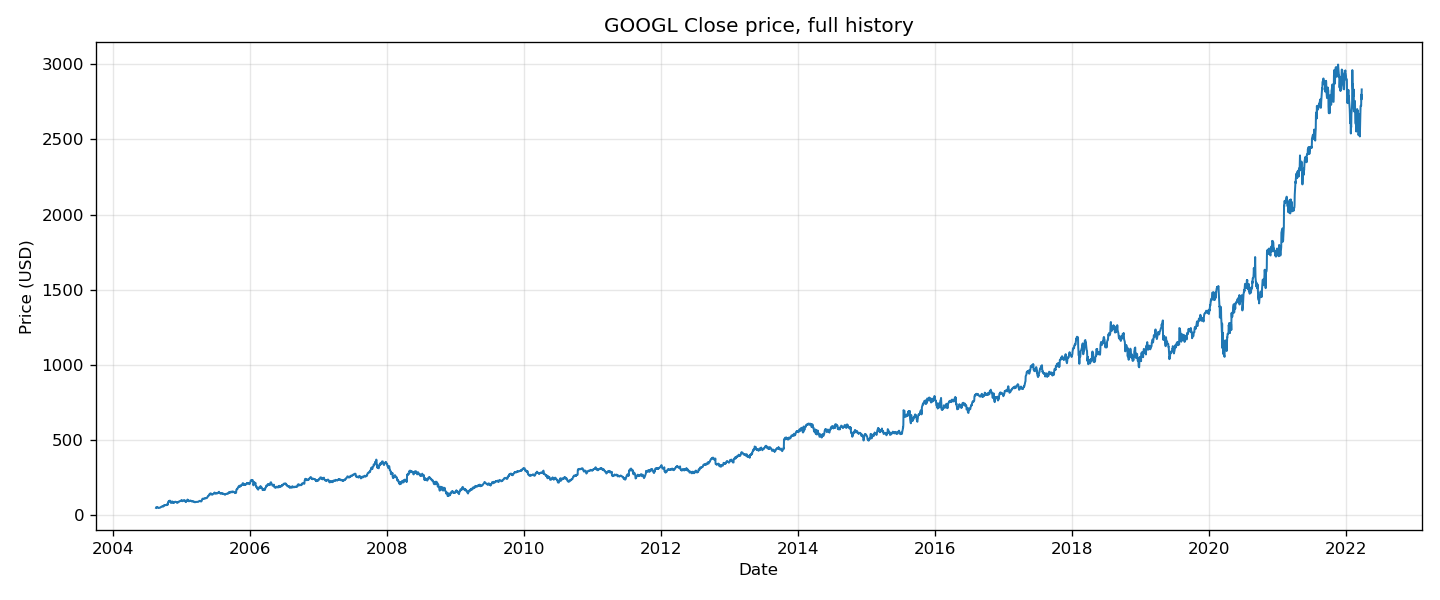

price_moving_averages.png


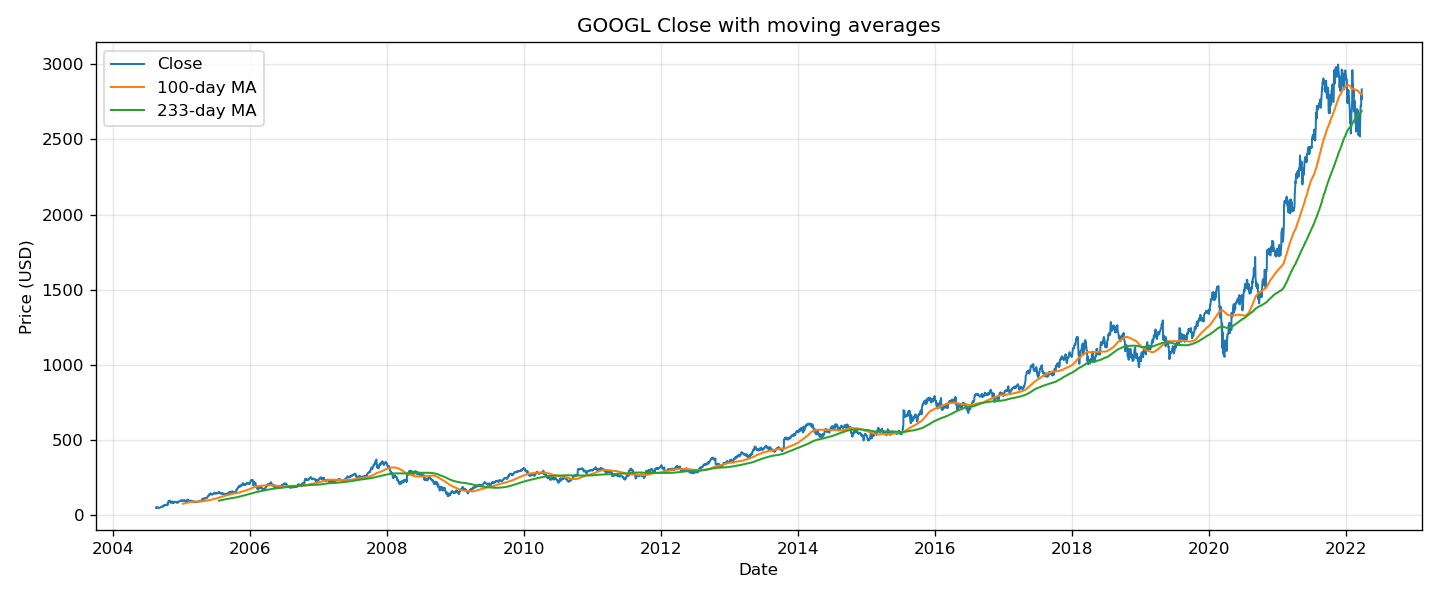

volume_history.png


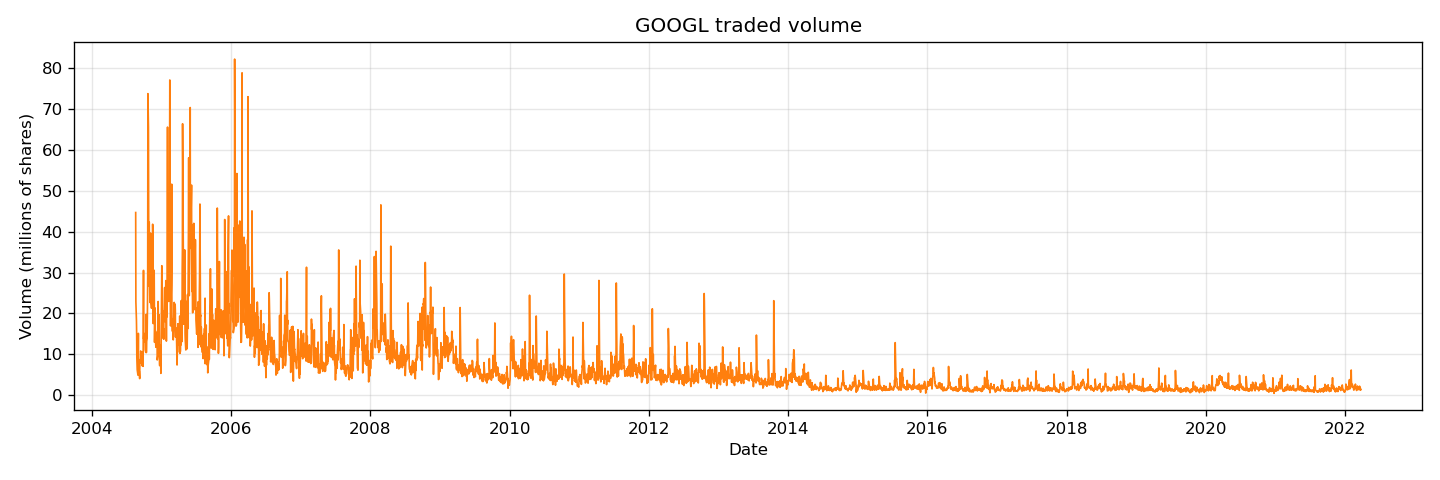

return_distribution.png


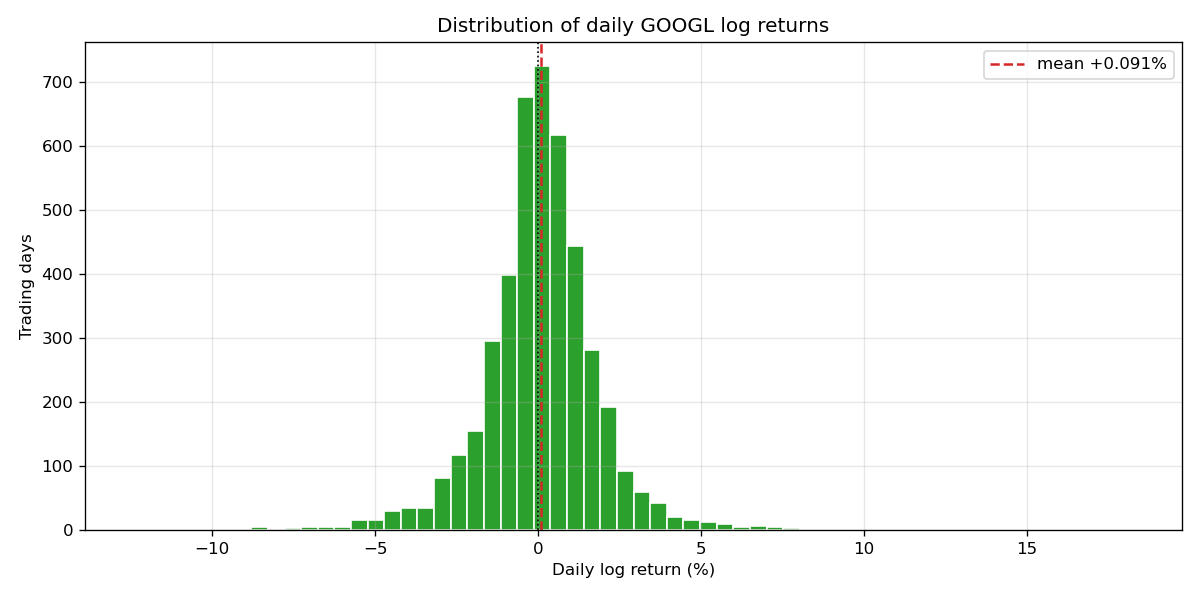

In [7]:
EDA_FIGURES = (
    'price_history.png',
    'price_moving_averages.png',
    'volume_history.png',
    'return_distribution.png',
)

for figure_name in EDA_FIGURES:
    print(figure_name)
    display(Image(filename=str(config.FIGURES_DIR / figure_name)))

Then three figures per target: the forecast against reality on the real date axis, the
error over time with its distribution, and the learning curve.

prediction_vs_actual_price.png


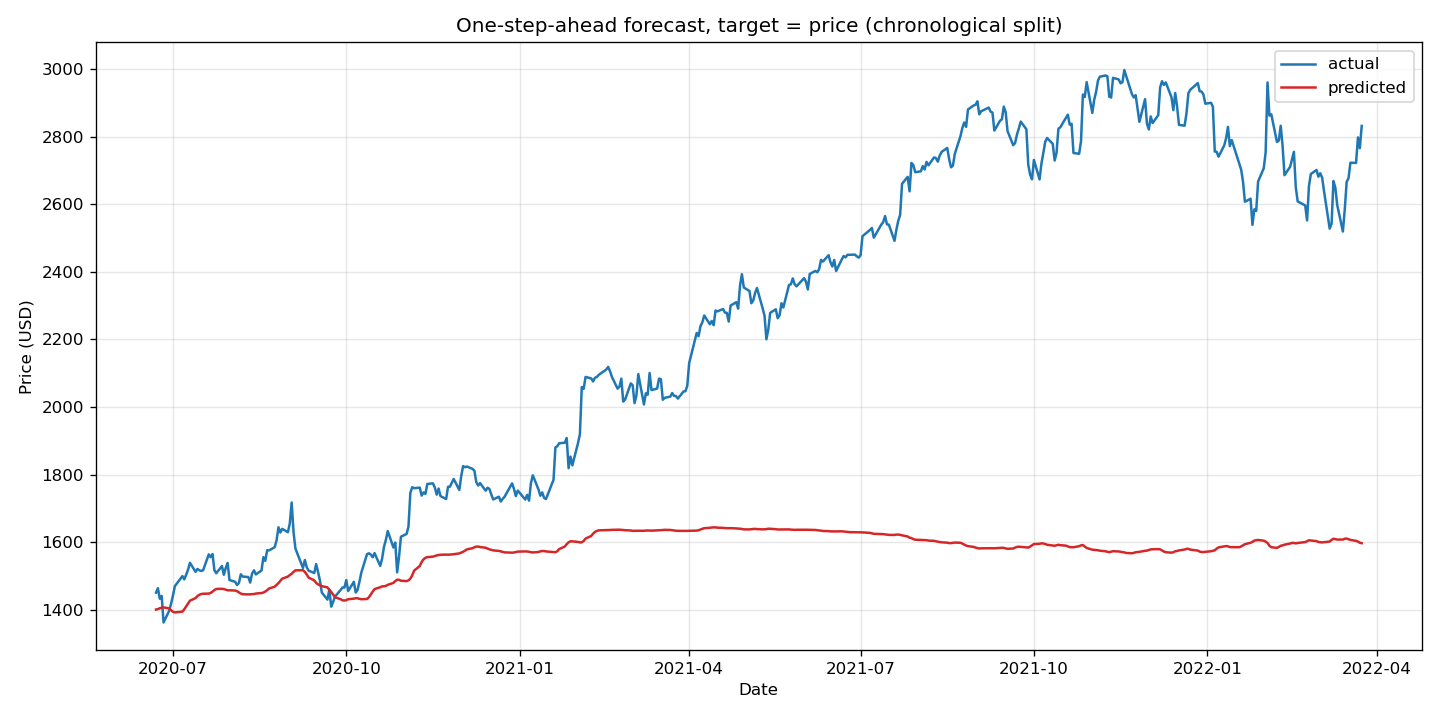

residuals_price.png


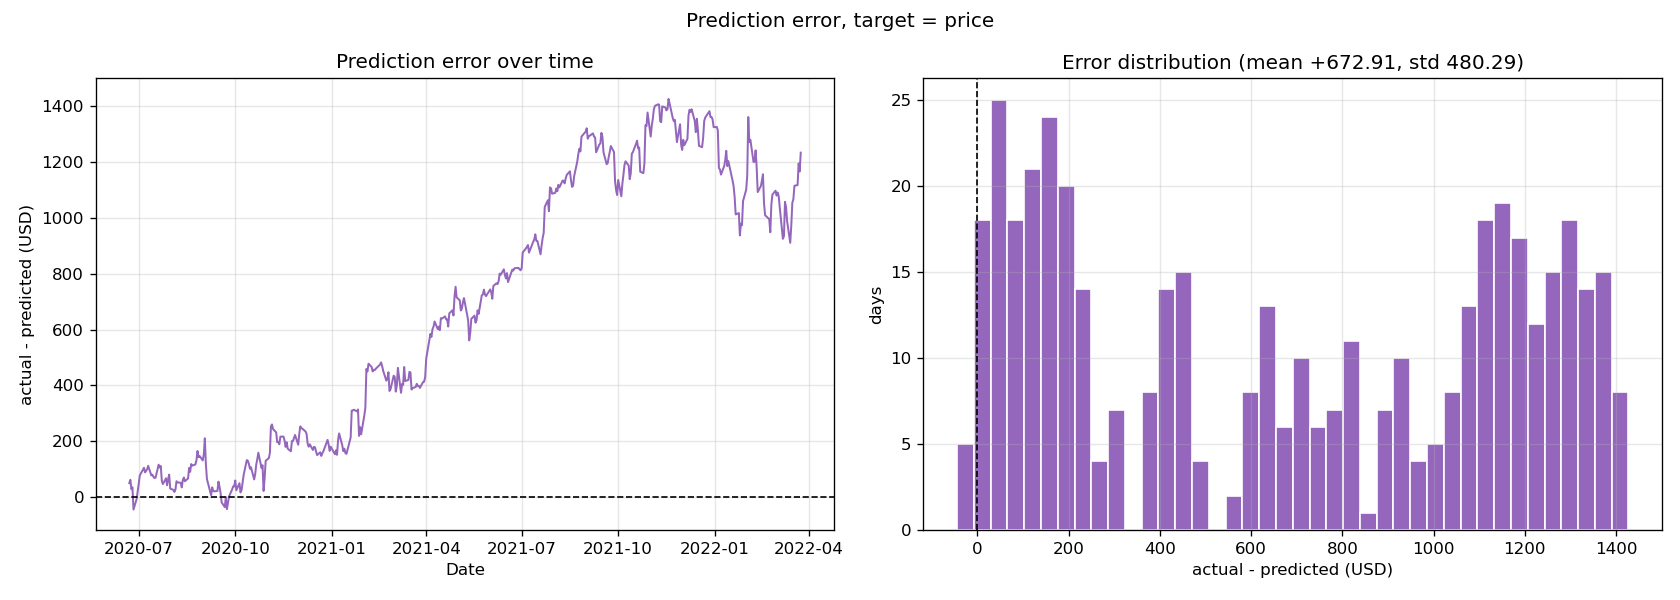

training_history_price.png


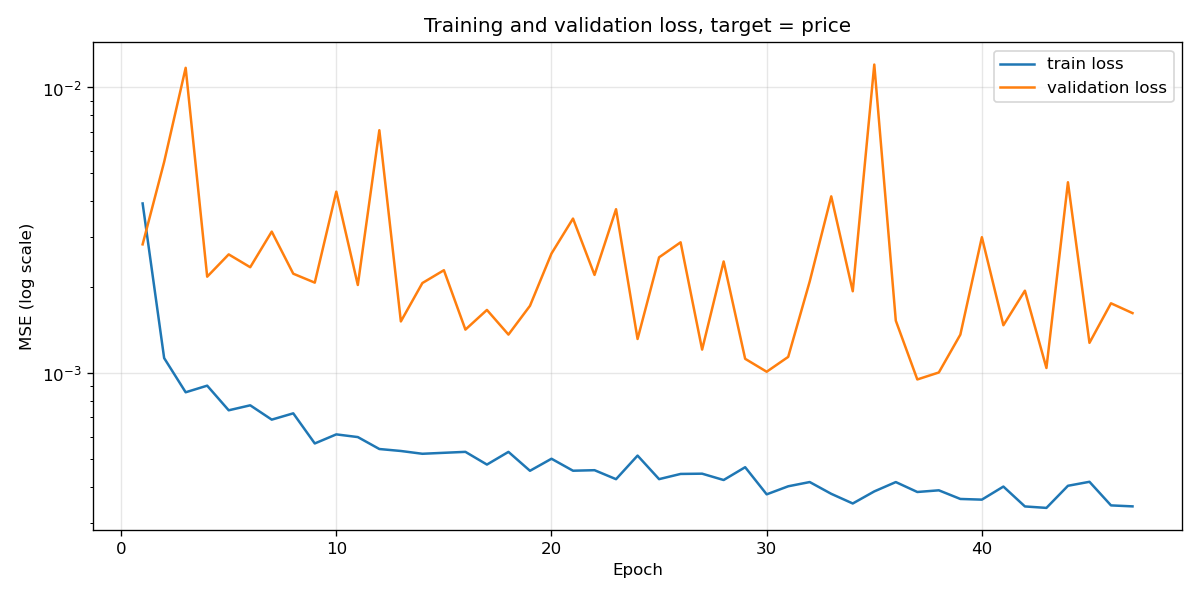

prediction_vs_actual_price_change.png


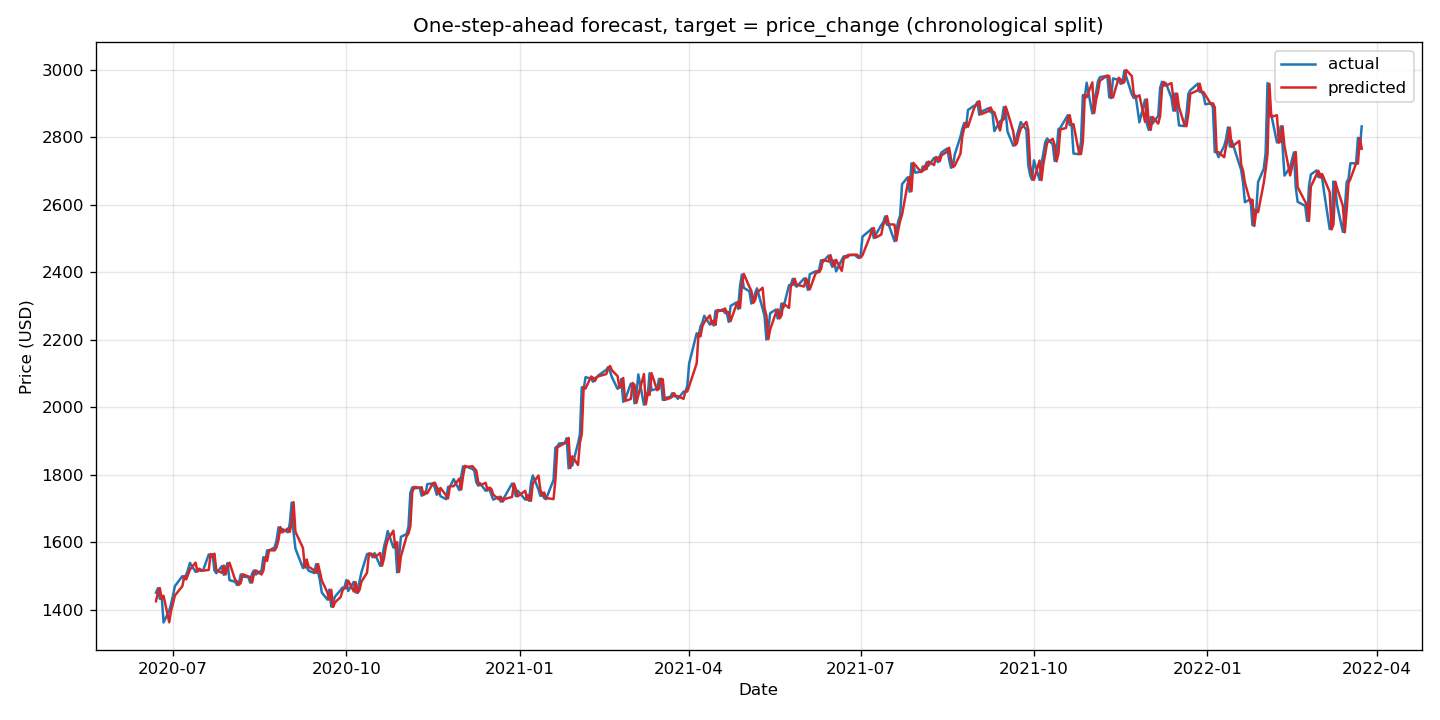

residuals_price_change.png


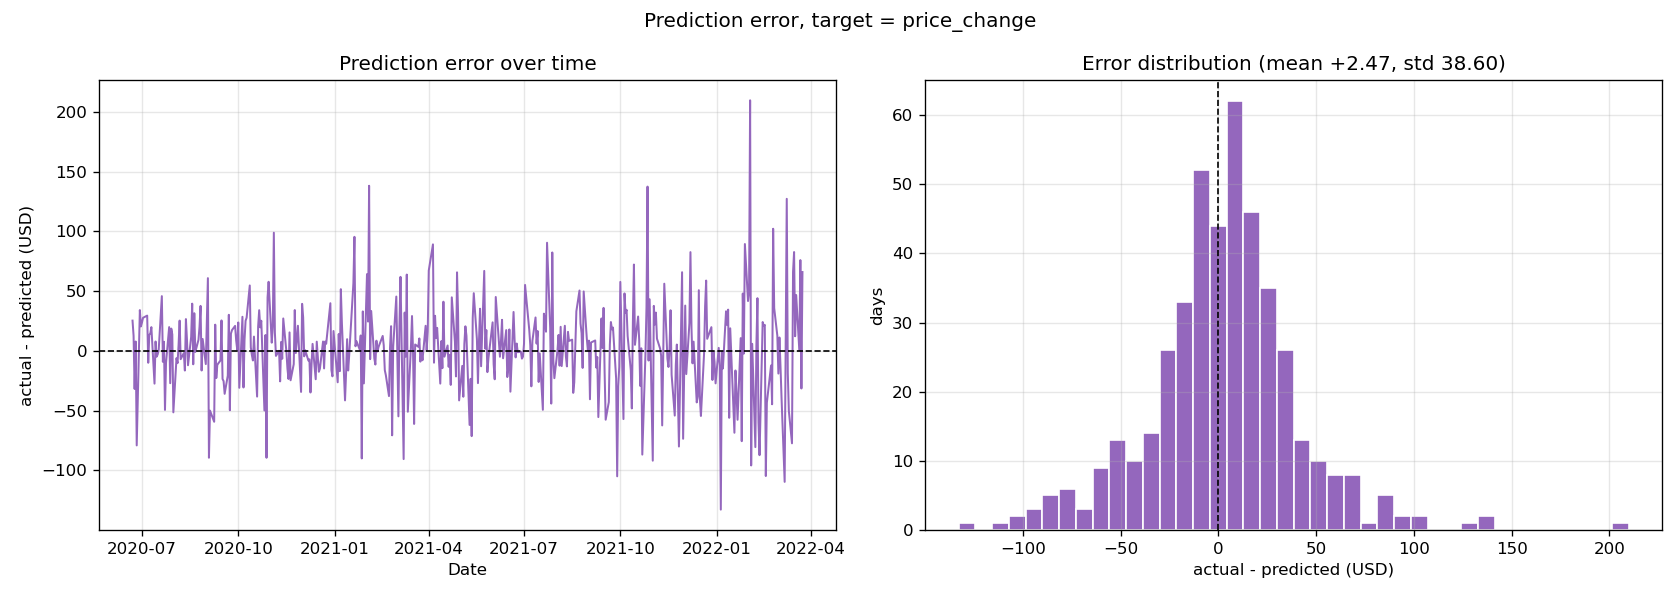

training_history_price_change.png


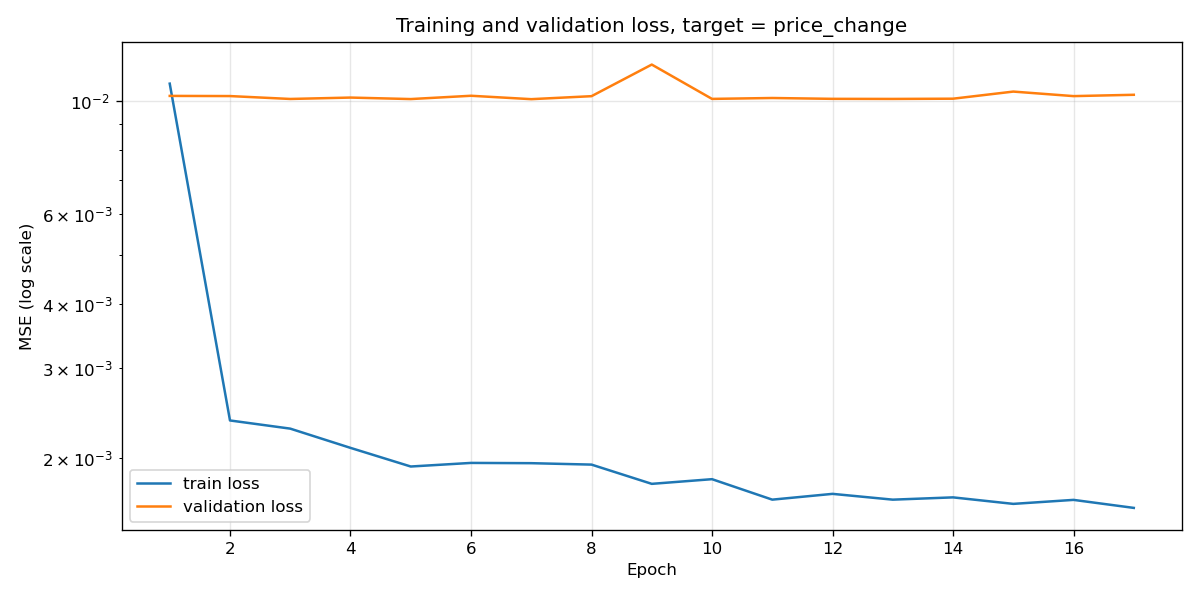

prediction_vs_actual_log_return.png


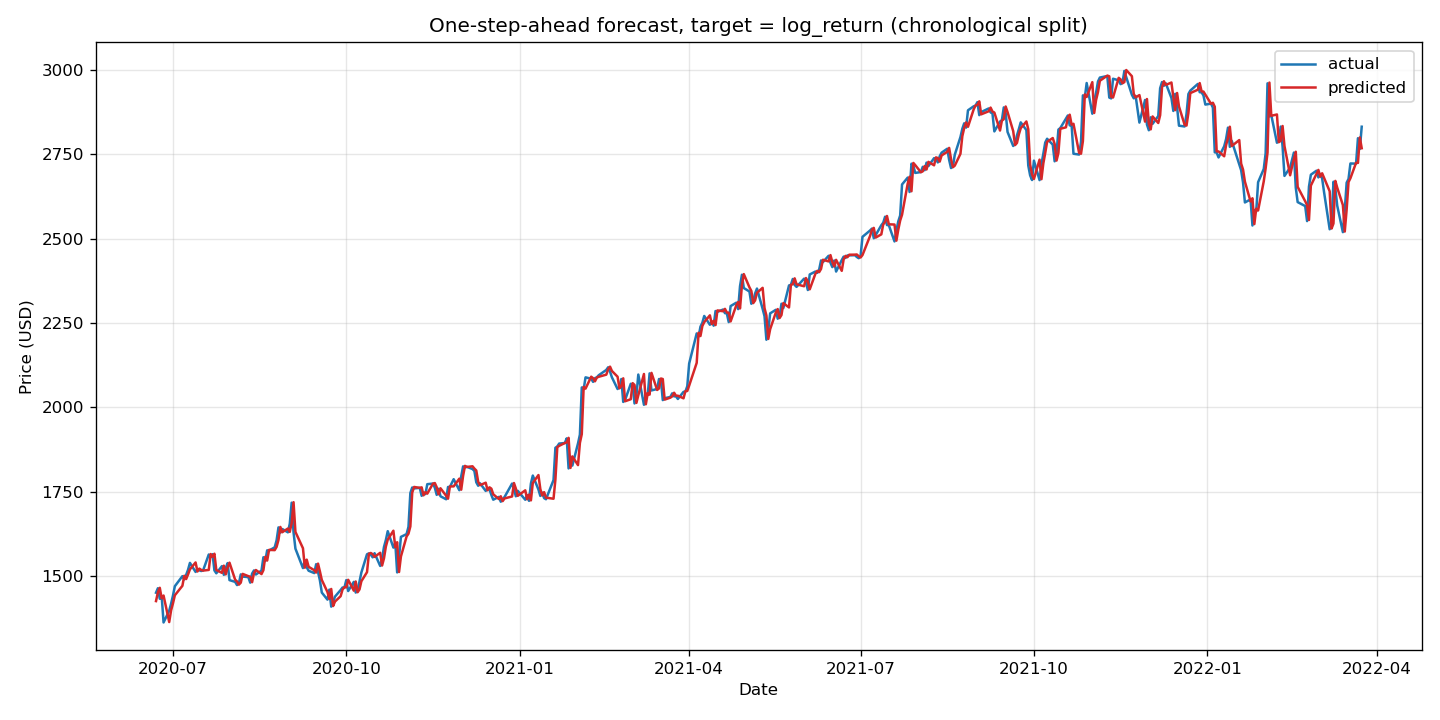

residuals_log_return.png


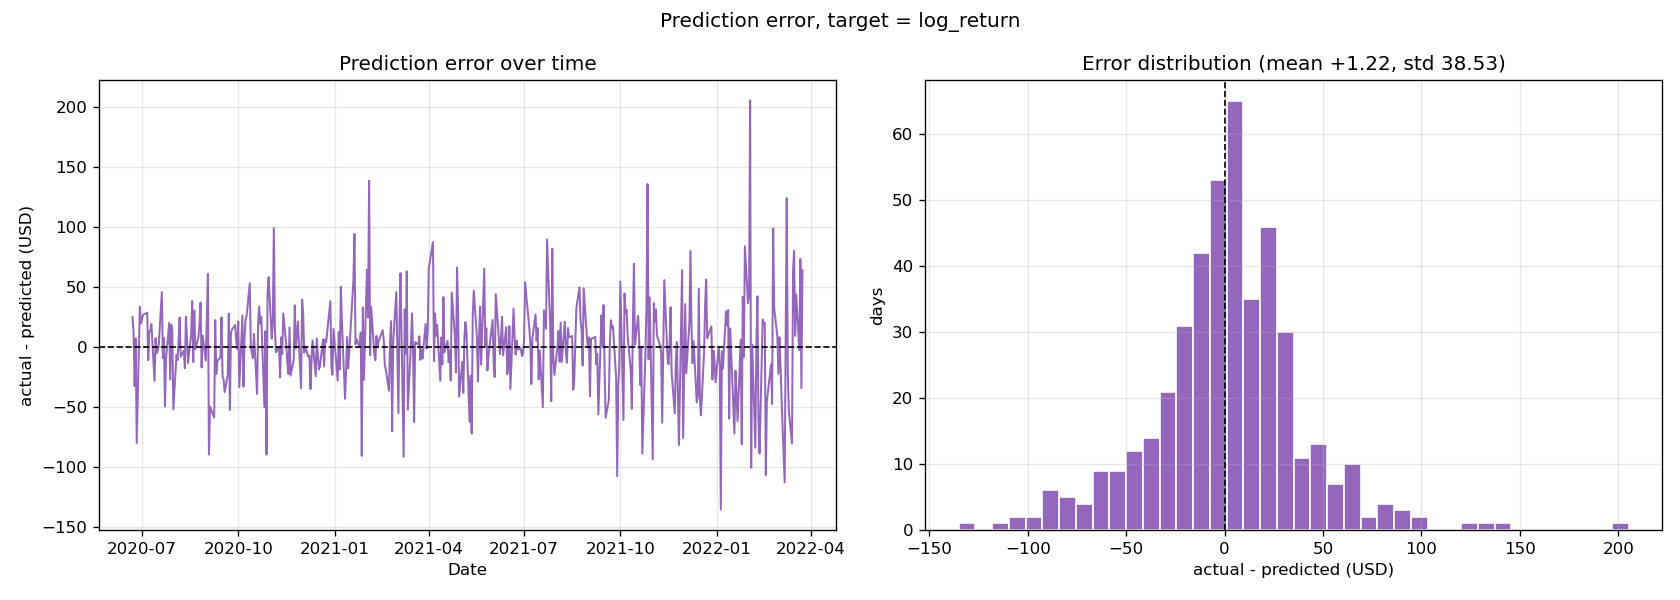

training_history_log_return.png


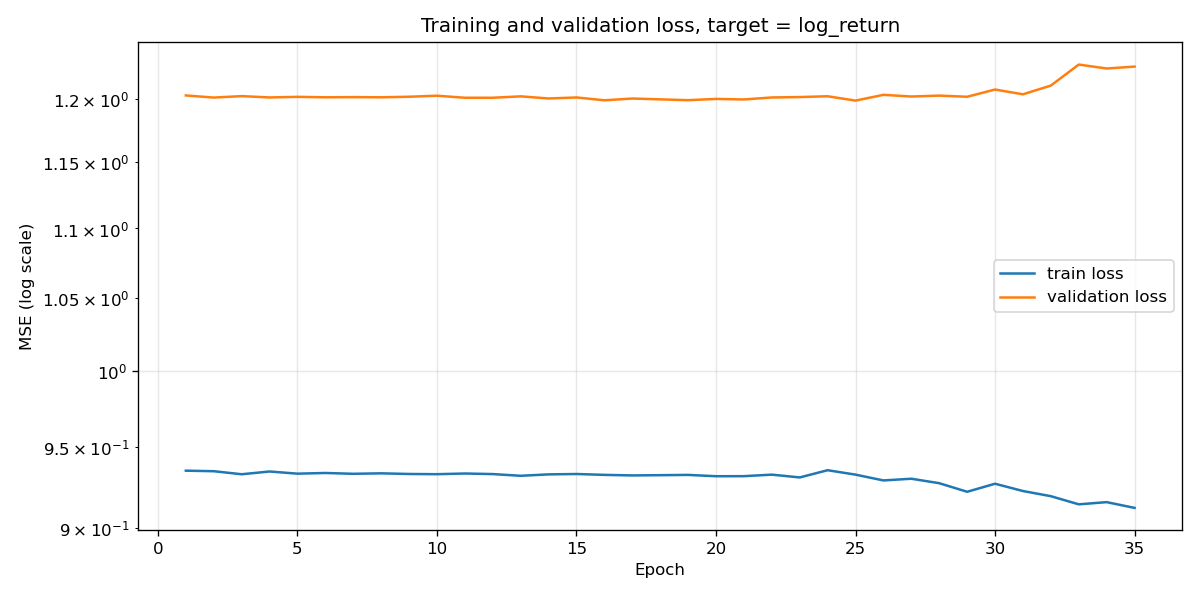

In [8]:
RUN_FIGURE_SUFFIXES = ('prediction_vs_actual', 'residuals', 'training_history')

for run in runs:
    for suffix in RUN_FIGURE_SUFFIXES:
        figure_name = f'{suffix}_{run.prediction_target}.png'
        print(figure_name)
        display(Image(filename=str(config.FIGURES_DIR / figure_name)))

## 7. Test suite

The 50 tests, run in a subprocess against the code that just produced the numbers
above. They are not decoration: the suite includes the check that would have caught the
original notebook's bug (`corr(window[-1], target) > 0.9` on the real data), an AST scan
of `src/` for any shuffling call, and regression tests for the extrapolation contrast
between the level and difference targets.

Running it as a subprocess rather than importing it keeps the kernel clean and makes the
result a real exit code. A non-zero exit raises, so this notebook cannot finish green
with a broken suite.

In [9]:
test_run = subprocess.run(
    [sys.executable, '-m', 'pytest', 'tests/', '-q'],
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    check=False,
)

print(test_run.stdout.strip())
if test_run.stderr.strip():
    print()
    print('stderr:')
    print(test_run.stderr.strip())
print()
print(f'pytest exit code: {test_run.returncode}')

if test_run.returncode != 0:
    raise RuntimeError('the test suite failed against the code that just ran')

..................................................                       [100%]
50 passed in 17.41s

pytest exit code: 0


## 8. What was written, and how to run one stage in isolation

`main()` is convenient but coarse. Every stage is also importable, so a cell can
retrain a single target without touching the other two - useful when tuning one
parameter. Flip the flag below to try it.

In [10]:
RERUN_SINGLE_TARGET = False
TARGET_TO_RERUN = config.LOG_RETURN_TARGET

if RERUN_SINGLE_TARGET:
    rerun = TARGET_RUNNERS[TARGET_TO_RERUN](prices, split, verbose=2)
    print(format_table(rerun.metrics_table, f're-run: {TARGET_TO_RERUN}'))
else:
    print('skipped: set RERUN_SINGLE_TARGET = True to retrain one target alone')
    print(f'available runners: {sorted(TARGET_RUNNERS)}')

print()
written_figures = sorted(path.name for path in config.FIGURES_DIR.glob('*.png'))
written_models = sorted(path.name for path in config.MODEL_DIR.glob('*.keras'))

print(f'figures in {config.FIGURES_DIR.name}/ : {len(written_figures)}')
for name in written_figures:
    print(f'  {name}')
print()
print(f'checkpoints in {config.MODEL_DIR.name}/ : {len(written_models)}')
for name in written_models:
    print(f'  {name}')

skipped: set RERUN_SINGLE_TARGET = True to retrain one target alone
available runners: ['log_return', 'price', 'price_change']

figures in figures/ : 16
  prediction_vs_actual_log_return.png
  prediction_vs_actual_price.png
  prediction_vs_actual_price_change.png
  price_history.png
  price_moving_averages.png
  residuals_log_return.png
  residuals_price.png
  residuals_price_change.png
  return_distribution.png
  training_history_log_return.png
  training_history_price.png
  training_history_price_change.png
  volume_history.png
  walkthrough_prediction_vs_actual.png
  walkthrough_residuals.png
  walkthrough_training_history.png

checkpoints in models/ : 3
  lstm_googl_log_return.keras
  lstm_googl_price.keras
  lstm_googl_price_change.keras


## 9. Reading the result

This notebook runs the project; it does not change what the project found. The honest
reading of the numbers above is in `README.md` section 4, and the short version is:

- The `price` level target loses to naive persistence by a wide margin, because a
  `MinMaxScaler` fitted on the training slice cannot encode a test period that trades
  far above it. That is reported, not hidden.
- `price_change` and `log_return` fix that particular problem, but their network output
  is nearly constant - `target var. ratio` well below 0.05 - and the price curve tracks
  the test period only because it is rebuilt from the previous close. Directional
  accuracy equal to the up-day share is the base rate, not skill.
- The single hairline RMSE win on `log_return` is 0.25%, with no significance test and
  no directional edge. The conclusion the repository stands behind is that **this LSTM
  does not beat tomorrow's price equals today's**.

To reproduce it from the command line instead:

```bash
python run_pipeline.py          # the same run, printing the same tables
python -m pytest tests/ -v      # the same 50 tests
```